In [1]:
# transfer learning is research problem in ML that focus on storing knowledge gained during solving one problem and
# applying it into different problem

In [3]:
pip install tensorflow_hub

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 700.8 kB/s eta 0:00:00 kB/s eta 0:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [tensorflow_hub]
Note: you may need to restart the kernel to use updated packages.


In [5]:
import numpy as np
import tensorflow_hub as hub
import matplotlib.pyplot as plt
import tensorflow as tf
import cv2
import PIL.Image as Image
import os

In [6]:
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras import layers

In [11]:
IMAGE_SHAPE = (224, 224)
classifier = keras.Sequential([
    keras.applications.MobileNetV2(input_shape=IMAGE_SHAPE+(3,))
])

14536120/14536120 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [12]:
IMAGE_SHAPE + (3,)

(224, 224, 3)

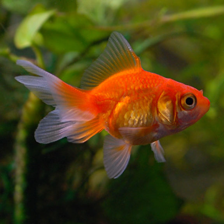

In [16]:
gold_fist_image = Image.open("goldfish.jpg").resize(IMAGE_SHAPE)
gold_fist_image

In [17]:
gold_fist_image = np.array(gold_fist_image) / 255.0

In [19]:
gold_fist_image[np.newaxis, ...].shape

(1, 224, 224, 3)

In [25]:
result = classifier.predict(gold_fist_image[np.newaxis, ...])
result.shape

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step


(1, 1000)

In [26]:
predicted_index = np.argmax(result)
predicted_index

np.int64(1)

In [27]:
image_labels = []

with open("ImageNetLabels.txt", "r") as f:
    image_labels = f.read().splitlines()

In [29]:
image_labels[:5]

['background', 'tench', 'goldfish', 'great white shark', 'tiger shark']

In [30]:
image_labels[predicted_index] #it makes wrong predictions !!

'tench'

In [33]:
dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"
data_dir = tf.keras.utils.get_file("flowers_photos", origin=dataset_url, cache_dir=".", untar=True)
data_dir

'./datasets/flowers_photos'

In [37]:
import pathlib

data_dir = pathlib.Path("datasets/flowers_photos/flower_photos")
data_dir

PosixPath('datasets/flowers_photos/flower_photos')

In [38]:
list(data_dir.glob("*/*.jpg"))[:5]

[PosixPath('datasets/flowers_photos/flower_photos/tulips/13471563274_471fc1db33_m.jpg'),
 PosixPath('datasets/flowers_photos/flower_photos/tulips/15149373026_93aacc65c5.jpg'),
 PosixPath('datasets/flowers_photos/flower_photos/tulips/5665080897_0796f726c9_m.jpg'),
 PosixPath('datasets/flowers_photos/flower_photos/tulips/8717900362_2aa508e9e5.jpg'),
 PosixPath('datasets/flowers_photos/flower_photos/tulips/13997627965_22d81601ce_n.jpg')]